# Random-reward CMAB: anchor grid and fine-beta zoom

This notebook compares the two completed six-state, two-action random-reward CMAB grids at $\gamma=0.9$. Circles are revealing solutions (zero accessible violations) and crosses are non-revealing solutions (one or more violations). The CMAB boundary is

$$\beta_{\min}(\epsilon)=\frac{\gamma\epsilon(1-\epsilon)}{1-\gamma^2}.$$

All revealing/non-revealing markers use full opacity. Solver precision is shown only in its dedicated diagnostic figure.

In [7]:
from pathlib import Path
import json

from IPython.display import Markdown, display
from matplotlib.colors import Normalize, SymLogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, Rectangle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPOSITORY_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'mdp.py').is_file()
)
DATA_DIR = (
    REPOSITORY_ROOT / 'experiments' / 'jpo_exps' / 'cmab_exps'
    / 'random_reward_revealing_grid'
)
PLOT_DIR = DATA_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_GAMMA = 0.9
SOURCES = [
    {
        'key': 'anchor',
        'directory': 'beta_00_05_10_15',
        'label': r'Anchor grid: $\beta=0,0.05,0.10,0.15$',
        'color': '#2f6fbb',
    },
    {
        'key': 'fine',
        'directory': 'beta_01_02_03_04_05',
        'label': r'Fine grid: $\beta=0.01,\ldots,0.05$',
        'color': '#b2473e',
    },
]

REQUIRED_COLUMNS = {
    'status', 'point_id', 'gamma', 'beta', 'epsilon', 'violation_count',
    'sarsop_gap', 'solver_stop_reason', 'discounted_transmission_occupancy',
}

def load_grid(source):
    result_path = DATA_DIR / source['directory'] / 'results.json'
    payload = json.loads(result_path.read_text(encoding='utf-8'))
    experiment = payload['experiment']
    points = pd.DataFrame(payload['points'])
    missing = REQUIRED_COLUMNS.difference(points.columns)
    assert not missing, f'{source["directory"]}: missing columns {sorted(missing)}'
    points = points[np.isclose(points['gamma'], TARGET_GAMMA)].copy()
    assert len(points) == experiment['expected_points']
    assert (points['status'] == 'ok').all()
    assert not points.duplicated(['beta', 'epsilon']).any()
    assert experiment['n_states'] == 6 and experiment['n_actions'] == 2
    assert experiment['solver']['initial_upper_bound'] == 'fully_observable'
    points['grid'] = source['key']
    points['grid_label'] = source['label']
    points['revealing'] = points['violation_count'].eq(0)
    return experiment, points.sort_values(['beta', 'epsilon']).reset_index(drop=True)

experiments = {}
grids = {}
for source in SOURCES:
    experiments[source['key']], grids[source['key']] = load_grid(source)

frame = pd.concat(grids.values(), ignore_index=True)
common_keys = ['mdp_type', 'n_states', 'n_actions', 'density', 'mdp_seed', 'gammas']
for key in common_keys:
    assert experiments['anchor'][key] == experiments['fine'][key]

summary = pd.DataFrame([
    {
        'grid': source['directory'],
        'points': len(grids[source['key']]),
        'revealing': int(grids[source['key']]['revealing'].sum()),
        'non_revealing': int((~grids[source['key']]['revealing']).sum()),
        'max_sarsop_gap': grids[source['key']]['sarsop_gap'].max(),
        'max_time_stops': int(grids[source['key']]['solver_stop_reason'].eq('max_time').sum()),
    }
    for source in SOURCES
])
display(summary)


,grid,points,revealing,non_revealing,max_sarsop_gap,max_time_stops
0,beta_00_05_10_15,40,30,10,0.326065,28
1,beta_01_02_03_04_05,50,27,23,0.070877,33


## 1. Each grid: revealing/non-revealing and the CMAB bound

The markers below deliberately do not encode solver gap. Both classes remain fully opaque.

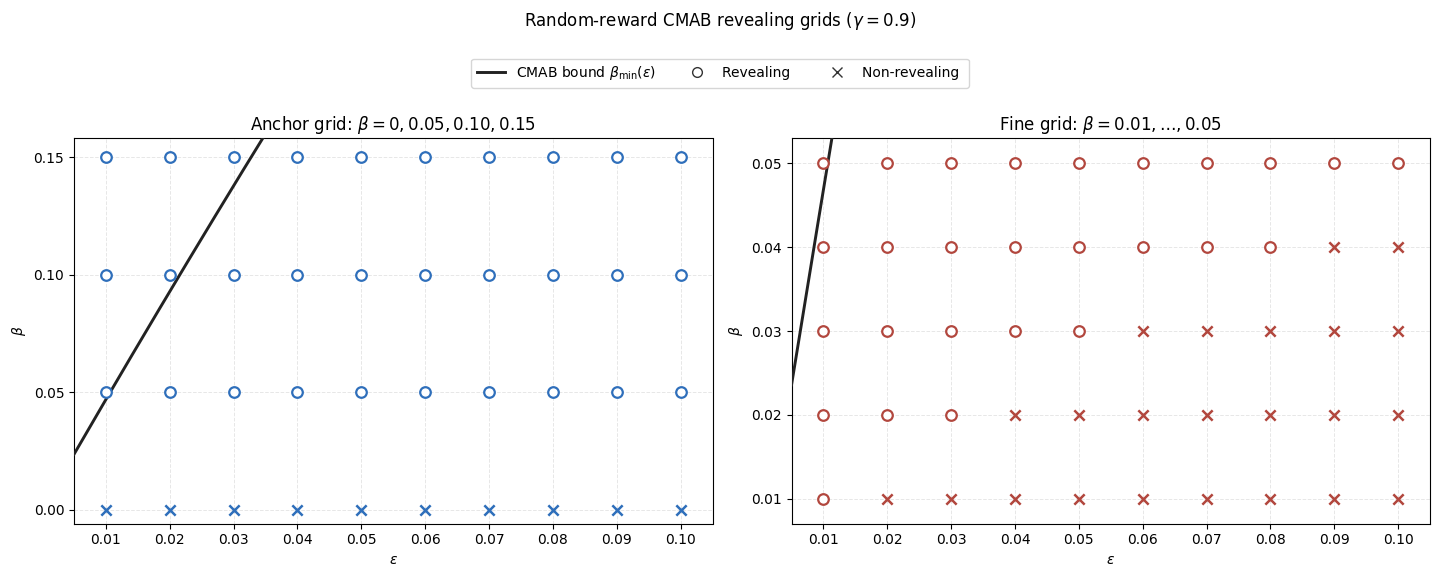

Figure saved to `experiments/jpo_exps/cmab_exps/random_reward_revealing_grid/plots/gamma_0p9_each_grid.png`.

In [8]:
def beta_min(epsilon, gamma=TARGET_GAMMA):
    epsilon = np.asarray(epsilon, dtype=float)
    return gamma * epsilon * (1.0 - epsilon) / (1.0 - gamma**2)

def add_revealing_points(ax, points, color):
    revealing = points[points['revealing']]
    non_revealing = points[~points['revealing']]
    ax.scatter(
        revealing['epsilon'], revealing['beta'], s=58, marker='o',
        facecolors='white', edgecolors=color, linewidths=1.6,
        alpha=1.0, zorder=4,
    )
    ax.scatter(
        non_revealing['epsilon'], non_revealing['beta'], s=55, marker='x',
        color=color, linewidths=1.8, alpha=1.0, zorder=5,
    )

def style_parameter_axis(ax, points, title, ylim):
    epsilon_dense = np.linspace(0.005, 0.105, 800)
    ax.plot(
        epsilon_dense, beta_min(epsilon_dense),
        color='#222222', linewidth=2.1, zorder=3,
    )
    ax.set_xlim(0.005, 0.105)
    ax.set_ylim(*ylim)
    ax.set_xticks(np.arange(0.01, 0.101, 0.01))
    ax.set_yticks(np.sort(points['beta'].unique()))
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel(r'$\beta$')
    ax.set_title(title)
    ax.grid(alpha=0.30, linestyle='--', linewidth=0.7)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
plot_settings = {
    'anchor': (-0.006, 0.158),
    'fine': (0.007, 0.053),
}
for ax, source in zip(axes, SOURCES):
    points = grids[source['key']]
    style_parameter_axis(ax, points, source['label'], plot_settings[source['key']])
    add_revealing_points(ax, points, source['color'])

legend_handles = [
    Line2D([0], [0], color='#222222', lw=2.1,
           label=r'CMAB bound $\beta_{\min}(\epsilon)$'),
    Line2D([0], [0], marker='o', linestyle='None', markersize=7,
           markerfacecolor='white', markeredgecolor='#333333',
           label='Revealing '),
    Line2D([0], [0], marker='x', linestyle='None', markersize=7,
           color='#333333', label='Non-revealing '),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), frameon=True)
fig.suptitle(r'Random-reward CMAB revealing grids ($\gamma=0.9$)', y=1.10)
fig.tight_layout()
OUTPUT_EACH_GRID = PLOT_DIR / 'gamma_0p9_each_grid.png'
fig.savefig(OUTPUT_EACH_GRID, dpi=220, bbox_inches='tight')
plt.show()
display(Markdown(f'Figure saved to `{OUTPUT_EACH_GRID.relative_to(REPOSITORY_ROOT)}`.'))


## 2. Solver precision

These heatmaps show the final SARSOP certificate $U-L$. A red cell border denotes a `max_time` stop. This diagnostic does not alter any point in the revealing/non-revealing plots.

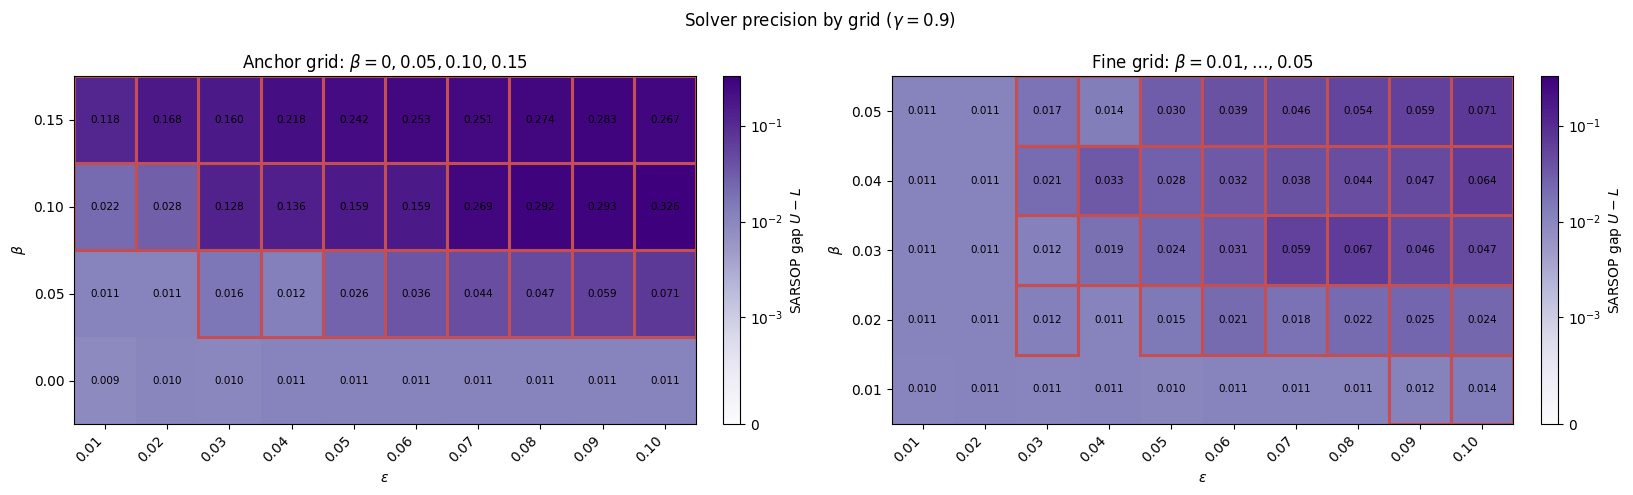

Figure saved to `experiments/jpo_exps/cmab_exps/random_reward_revealing_grid/plots/gamma_0p9_solver_precision.png`.

In [9]:
def grid_matrix(points, column):
    betas = np.sort(points['beta'].unique())
    epsilons = np.sort(points['epsilon'].unique())
    matrix = (
        points.pivot(index='beta', columns='epsilon', values=column)
        .reindex(index=betas, columns=epsilons)
    )
    return matrix, betas, epsilons

def draw_heatmap(ax, points, column, title, cmap, norm, formatter):
    matrix, betas, epsilons = grid_matrix(points, column)
    values = matrix.to_numpy(dtype=float)
    image = ax.imshow(values, origin='lower', aspect='auto', cmap=cmap, norm=norm)
    for row, column_index in np.argwhere(np.isfinite(values)):
        ax.text(column_index, row, formatter(values[row, column_index]),
                ha='center', va='center', fontsize=7.5)
    ax.set_xticks(range(len(epsilons)), [f'{value:.2f}' for value in epsilons],
                  rotation=45, ha='right')
    ax.set_yticks(range(len(betas)), [f'{value:.2f}' for value in betas])
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylabel(r'$\beta$')
    ax.set_title(title)
    return image

finite_gaps = frame['sarsop_gap'].to_numpy(dtype=float)
finite_gaps = finite_gaps[np.isfinite(finite_gaps)]
gap_norm = SymLogNorm(
    linthresh=1e-3, vmin=0.0,
    vmax=max(1e-3, float(finite_gaps.max())),
)

fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.0))
for ax, source in zip(axes, SOURCES):
    points = grids[source['key']]
    image = draw_heatmap(
        ax, points, 'sarsop_gap', source['label'], 'Purples', gap_norm,
        lambda value: f'{value:.3f}',
    )
    stop_matrix, _, _ = grid_matrix(points, 'solver_stop_reason')
    for row, column_index in np.argwhere(stop_matrix.to_numpy(dtype=object) == 'max_time'):
        ax.add_patch(Rectangle(
            (column_index - 0.5, row - 0.5), 1, 1,
            fill=False, edgecolor='#c44e52', linewidth=2.2,
        ))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label='SARSOP gap $U-L$')

fig.suptitle(r'Solver precision by grid ($\gamma=0.9$)')
fig.tight_layout()
OUTPUT_PRECISION = PLOT_DIR / 'gamma_0p9_solver_precision.png'
fig.savefig(OUTPUT_PRECISION, dpi=220, bbox_inches='tight')
plt.show()
display(Markdown(f'Figure saved to `{OUTPUT_PRECISION.relative_to(REPOSITORY_ROOT)}`.'))


## 3. Discounted transmission occupancy

Both grids use the same absolute scale $[0,\gamma/(1-\gamma)]=[0,9]$.

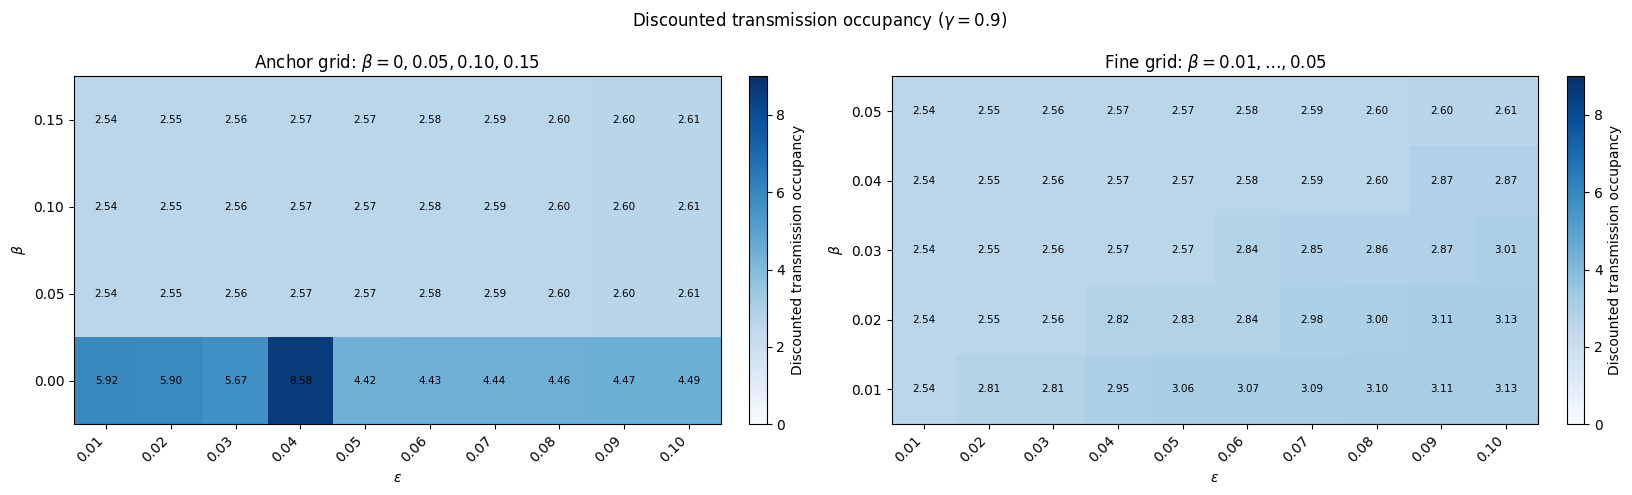

Figure saved to `experiments/jpo_exps/cmab_exps/random_reward_revealing_grid/plots/gamma_0p9_discounted_transmission.png`.

In [10]:
transmission_norm = Normalize(vmin=0.0, vmax=TARGET_GAMMA / (1.0 - TARGET_GAMMA))
fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.0))
for ax, source in zip(axes, SOURCES):
    image = draw_heatmap(
        ax, grids[source['key']], 'discounted_transmission_occupancy',
        source['label'], 'Blues', transmission_norm,
        lambda value: f'{value:.2f}',
    )
    fig.colorbar(
        image, ax=ax, fraction=0.046, pad=0.04,
        label='Discounted transmission occupancy',
    )

fig.suptitle(r'Discounted transmission occupancy ($\gamma=0.9$)')
fig.tight_layout()
OUTPUT_TRANSMISSION = PLOT_DIR / 'gamma_0p9_discounted_transmission.png'
fig.savefig(OUTPUT_TRANSMISSION, dpi=220, bbox_inches='tight')
plt.show()
display(Markdown(f'Figure saved to `{OUTPUT_TRANSMISSION.relative_to(REPOSITORY_ROOT)}`.'))


## 4. Anchor grid with fine-beta zoom

This reproduces the control-setting full-grid/zoom layout using the two random-reward CMAB grids. Marker opacity remains fixed at one.

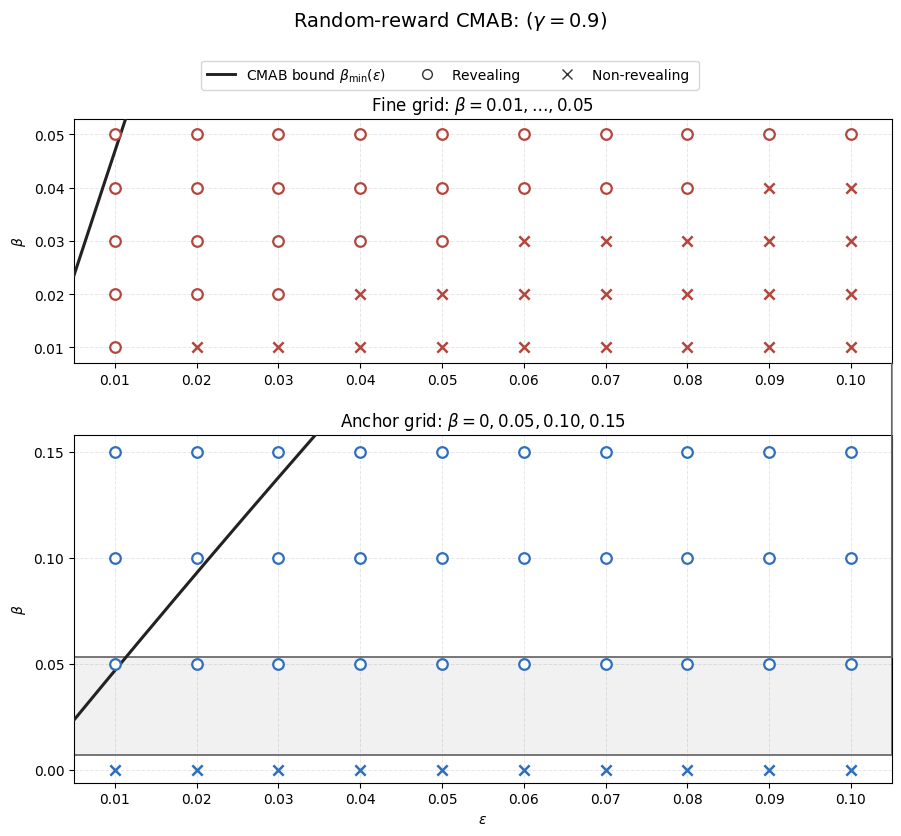

Figure saved to `experiments/jpo_exps/cmab_exps/random_reward_revealing_grid/plots/gamma_0p9_fullgrid_zoom.png`.

In [11]:
epsilon_dense = np.linspace(0.005, 0.105, 800)
fig = plt.figure(figsize=(9.4, 8.1))
layout = fig.add_gridspec(2, 1, height_ratios=[0.95, 1.35], hspace=0.24)
ax_zoom = fig.add_subplot(layout[0])
ax_anchor = fig.add_subplot(layout[1])

for ax in (ax_zoom, ax_anchor):
    ax.plot(epsilon_dense, beta_min(epsilon_dense),
            color='#222222', linewidth=2.2, zorder=3)
    ax.set_xlim(0.005, 0.105)
    ax.set_xticks(np.arange(0.01, 0.101, 0.01))
    ax.set_ylabel(r'$\beta$')
    ax.grid(alpha=0.30, linestyle='--', linewidth=0.7)

add_revealing_points(ax_zoom, grids['fine'], SOURCES[1]['color'])
add_revealing_points(ax_anchor, grids['anchor'], SOURCES[0]['color'])
ax_zoom.set_ylim(0.007, 0.053)
ax_zoom.set_yticks(np.sort(grids['fine']['beta'].unique()))
ax_zoom.set_title(SOURCES[1]['label'])
ax_anchor.set_ylim(-0.006, 0.158)
ax_anchor.set_yticks(np.sort(grids['anchor']['beta'].unique()))
ax_anchor.set_xlabel(r'$\epsilon$')
ax_anchor.set_title(SOURCES[0]['label'])

zoom_rectangle = Rectangle(
    (0.005, 0.007), 0.100, 0.046,
    facecolor=(0.55, 0.55, 0.55, 0.12),
    edgecolor='#666666', linewidth=1.25, zorder=2,
)
ax_anchor.add_patch(zoom_rectangle)
connector = ConnectionPatch(
    xyA=(0.105, 0.053), coordsA='data', axesA=ax_anchor,
    xyB=(0.105, 0.007), coordsB='data', axesB=ax_zoom,
    color='#666666', linewidth=1.25, clip_on=False, zorder=1,
)
fig.add_artist(connector)
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 0.98), frameon=True)
fig.suptitle(r'Random-reward CMAB: ($\gamma=0.9$)',
             y=1.035, fontsize=14)
fig.subplots_adjust(left=0.10, right=0.97, bottom=0.08, top=0.90)
OUTPUT_ZOOM = PLOT_DIR / 'gamma_0p9_fullgrid_zoom.png'
fig.savefig(OUTPUT_ZOOM, dpi=220, bbox_inches='tight')
plt.show()
display(Markdown(f'Figure saved to `{OUTPUT_ZOOM.relative_to(REPOSITORY_ROOT)}`.'))
